In [13]:
from langgraph.graph import StateGraph, START , END 
from typing import TypedDict

In [14]:
class BatsmanState(TypedDict):
    runs:int 
    balls:int
    fours:int 
    sixes:int 

    sr:float
    bpb:float
    bp:float
    summary:str
    

In [15]:
def calculate_sr (state:BatsmanState)->BatsmanState:
    sr = (state["runs"]/state["balls"])*100
    state['sr'] = sr 
    return {"sr":sr}

def calculate_bpb (state:BatsmanState)->BatsmanState:
    bpb = (state["balls"]/(state["fours"]+ state["sixes"]))
    state['bpb'] = bpb
    return {"bpb":bpb}

def calculate_bp (state:BatsmanState):
    bp = ((state["fours"]*4 + state["sixes"]*6)/state["runs"])*100
    state["bp"] = bp 
    return {"bp":bp}

def gen_summary (state:BatsmanState):
    summary = f"""
    strike rate - {state["sr"]}\n
    Balls per boundery - {state["bpb"]}\n
    Boundry percent - {state["bp"]}
    """
    state["summary"] = summary 
    return {"summary":summary}

In [16]:
#define graph 
graph = StateGraph(BatsmanState)

#define nodes 
graph.add_node("calculate_sr",calculate_sr)
graph.add_node("calculate_bpb",calculate_bpb)
graph.add_node("calculate_bp", calculate_bp)
graph.add_node("gen_summary",gen_summary)

#define edges connection
graph.add_edge(START , "calculate_sr")
graph.add_edge(START , "calculate_bpb")
graph.add_edge(START , "calculate_bp")

graph.add_edge("calculate_sr","gen_summary")
graph.add_edge("calculate_bpb","gen_summary")
graph.add_edge("calculate_bp","gen_summary")

graph.add_edge("gen_summary",END)

#compile graph 
workflow = graph.compile()


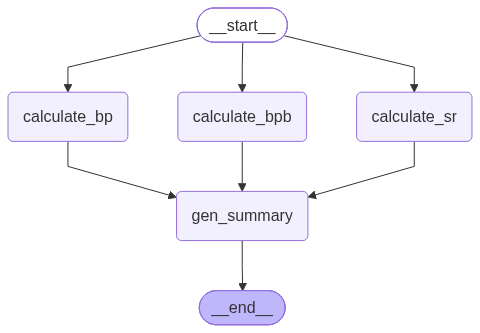

In [17]:
from IPython.display import Image 
Image(workflow.get_graph().draw_mermaid_png())

In [18]:
initial_state = {'runs':100 , "balls":50 , "fours":6, "sixes": 4}
final_state = workflow.invoke(initial_state)


In [19]:
print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'bp': 48.0, 'summary': '\n    strike rate - 200.0\n\n    Balls per boundery - 5.0\n\n    Boundry percent - 48.0\n    '}
